# Circular Dichroism (CD) Spectrum Analysis

This notebook demonstrates the step-by-step analysis of a single CD spectrum for a protein sample. We will cover data import, averaging multiple scans, smoothing, buffer baseline subtraction, and conversion to mean residue ellipticity (MRE).



## Step 1: Import Required Libraries

We start by importing the necessary Python libraries for data manipulation, file handling, plotting, and signal processing.

- `pandas` for data handling
- `os` for file paths
- `matplotlib.pyplot` for plotting
- `scipy.signal.savgol_filter` for smoothing the spectra

In [11]:
import pandas as pd
import os
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter

## Step 2: Define Protein Parameters

Here we define the key parameters for the protein sample. These are essential for converting the raw CD data to meaningful units.

**Important parameters to adjust:**
- `protein_name`: Name of your protein (e.g., "Myo" for Myoglobin)
- `protein_concentration`: Concentration in g/L (same value as mg/ml)
- `protein_resn`: Number of amino acid residues in the protein
- `protein_MW`: Molecular weight in Da (Daltons)
- `path_length`: Path length of the cuvette in cm (typically 0.1 cm)

Change these values according to your experimental setup!

In [12]:
protein_name = "ppBAT"
protein_concentration = 0.09575 # concentration in g/L
protein_resn = 154 # number of residues
protein_MW = 19150 # in Da  
path_length = 0.1 # in cm

## Step 3: Set File Paths

Specify the directory and file names for the protein and buffer spectra data.

**Parameters to change:**
- `base_directory`: The folder containing your data files (e.g., "./Myo" or "./ConA")
- `spectra_file`: The CSV file with protein CD data
- `buffer_file`: The CSV file with buffer baseline data

Ensure the files exist in the specified directory!
Have a look at the files in an editor to find out about the file structure. 
This will help you understand the following functions for data reading and interpretation.

In [13]:
import os
base_directory = "./ppBAT"
spectra_file = os.path.join(base_directory, "ppBat00007.csv")
buffer_file = os.path.join(base_directory, "buffer_Pi_NaF00002.csv")

## Step 4: Define Data Reading Function

This function reads the CD spectrometer output files, which contain multiple scans of CD, HV (high voltage), and absorbance data.

The function:
- Parses the CSV file to find sections for CD, HV, and Absorbance
- Extracts wavelength and signal data for each scan
- Calculates average signals across all scans
- Returns a dictionary of dataframes (for CD, HV and Absorbance)

**Note:** The file format is specific to the CD spectrometer used. If your data format differs, this function may need modification.

Also already keep in mind that your blank scan should be performed with the same settings as the protein scan.

In [18]:
def read_spectra(file_path):

    # read the first column only of the spectra file
    spectra_df = pd.read_csv(file_path, usecols=[0], skip_blank_lines=False)

    # find the indices of 'CircularDichroism' 'HV' and 'Absorbance'
    cd_index = []
    hv_index = []
    abs_index = []

    for i, row in enumerate(spectra_df.iloc[:, 0]):
        # print(f"Index {i}: {row}")
        if row == 'CircularDichroism':
            cd_index.append(i)
        elif row == 'HV':
            hv_index.append(i)
        elif row == 'Absorbance':
            abs_index.append(i)

    nrows = (hv_index[1] - cd_index[1]) - 4

    cd_df = pd.read_csv(file_path, skiprows=cd_index[1] + 4, nrows=nrows, header=None)
    cd_df.columns = ['Wavelength'] + [f'CD_{i}' for i in range(1, cd_df.shape[1])]
    cd_df['CD_Average'] = cd_df.iloc[:, 1:].mean(axis=1)

    hv_df = pd.read_csv(file_path, skiprows=hv_index[1] + 4, nrows=nrows, header=None)
    hv_df.columns = ['Wavelength'] + [f'HV_{i}' for i in range(1, hv_df.shape[1])]
    hv_df['HV_Average'] = hv_df.iloc[:, 1:].mean(axis=1)

    abs_df = pd.read_csv(file_path, skiprows=abs_index[1] + 4, nrows=nrows, header=None)
    abs_df.columns = ['Wavelength'] + [f'Abs_{i}' for i in range(1, abs_df.shape[1])]
    abs_df['Abs_Average'] = abs_df.iloc[:, 1:].mean(axis=1)

    return {
        'cd': cd_df,
        'hv': hv_df,
        'abs': abs_df,
    }


## Step 5: Load the Spectra Data

Using the read_spectra function, we load both the protein sample and buffer data.

The data is stored in dictionaries containing DataFrames for CD, HV, and absorbance measurements.

In [20]:
protein_spectra = read_spectra("ppBat00007.csv")
buffer_spectra = read_spectra("buffer_Pi_NaF00002.csv")
cd_df = protein_spectra["cd"]

Familiarize yourself with the data structure and how to call certain parts. Examples are given in the following cells

In [21]:
protein_spectra

{'cd':     Wavelength      CD_1        CD_2       CD_3         CD_4        CD_5  \
 0          260  -1.25820   -1.111830   -1.26317     -1.22314   -1.042020   
 1          259  -1.28713   -1.174620   -1.10951     -1.04506   -0.927993   
 2          258  -1.15930   -1.121810   -1.26135     -1.32785   -1.322650   
 3          257  -1.36282   -0.724389   -1.32591     -1.13296   -0.950356   
 4          256  -1.28333   -1.266530   -1.16107     -1.38342   -1.132370   
 ..         ...       ...         ...        ...          ...         ...   
 76         184  11.98060   55.782100  -15.92490     20.64130   35.717500   
 77         183 -73.33420  144.506000 -346.70800     50.75620 -324.267000   
 78         182 -51.56670 -183.386000  299.42900    224.11900 -319.439000   
 79         181  80.29480  188.126000 -225.74800 -12453.50000 -158.396000   
 80         180 -72.10640  447.990000  359.98200    669.89900  369.667000   
 
           CD_6      CD_7      CD_8       CD_9      CD_10   CD_Avera

In [22]:
protein_spectra["cd"]

,Wavelength,CD_1,CD_2,CD_3,CD_4,CD_5,CD_6,CD_7,CD_8,CD_9,CD_10,CD_Average
0,260,-1.25820,-1.111830,-1.26317,-1.22314,-1.042020,-1.372960,-1.06658,-1.32660,-1.08391,-1.14509,-1.189350
1,259,-1.28713,-1.174620,-1.10951,-1.04506,-0.927993,-1.105090,-1.40061,-1.20895,-1.32742,-1.14953,-1.173591
2,258,-1.15930,-1.121810,-1.26135,-1.32785,-1.322650,-1.124930,-1.32170,-1.24169,-1.21363,-1.16979,-1.226470
3,257,-1.36282,-0.724389,-1.32591,-1.13296,-0.950356,-0.925108,-1.24992,-1.15669,-1.21003,-1.05963,-1.109781
4,256,-1.28333,-1.266530,-1.16107,-1.38342,-1.132370,-1.105550,-1.12929,-1.31236,-1.27660,-1.08645,-1.213697
...,...,...,...,...,...,...,...,...,...,...,...,...
76,184,11.98060,55.782100,-15.92490,20.64130,35.717500,179.936000,43.55310,-59.84630,191.23900,17.75690,48.083530
77,183,-73.33420,144.506000,-346.70800,50.75620,-324.267000,390.701000,-23.37100,-78.09730,-26.33570,961.42600,67.527600
78,182,-51.56670,-183.386000,299.42900,224.11900,-319.439000,135.764000,43.08020,-11.00820,-241.32800,758.74100,65.440530
79,181,80.29480,188.126000,-225.74800,-12453.50000,-158.396000,-178.034000,-14.12460,-38.38920,-199.65400,311.06100,-1268.836400


In [23]:
protein_spectra["cd"]["Wavelength"]

0     260
1     259
2     258
3     257
4     256
     ... 
76    184
77    183
78    182
79    181
80    180
Name: Wavelength, Length: 81, dtype: int64

## Step 6: Visualize Raw Data

Let's plot the individual scans to assess data quality and reproducibility.

**CD Spectrum:** Shows the circular dichroism signal for each scan. Good reproducibility indicates stable measurement conditions.

**HV (High Voltage):** Monitors the detector voltage. The detector voltage is increased when the Absorbance increases to keep the CD-signal measurable. Buffer components and protein concentration play an important role to which wavelengths CD-signal is still measurable. Every component that contributes to Absorbance in far UV can and will disturb the measurements (e.g. $Cl^{-}$, Tris, MOPS, etc.). This is a crucial measure to validate your experimental design. If you cannot measure reliably think of altering your buffer system. Low concentration phosphate buffers with low salt concentration are best suitable for CD. If the protein needs a certain ionic strength NaCl can be substituted by NaF. You have to find a sweet spot between measurability and keeping your protein happy.

**Absorbance:** Shows the absorption at each wavelength. High absorbance (>2) can distort CD measurements.

Look for any outliers or noisy scans that might need exclusion.

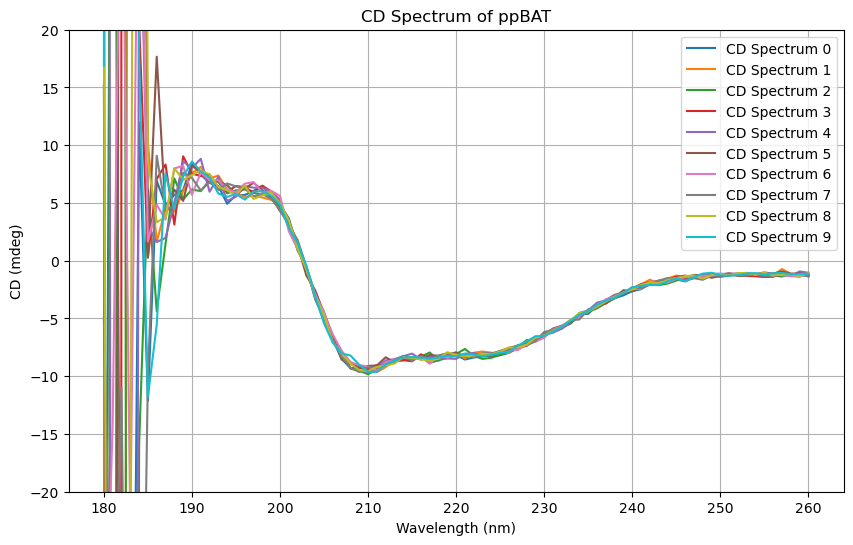

In [24]:
# plot the CD spectrum
plt.figure(figsize=(10, 6))
for i in range(protein_spectra['cd'].shape[1]-2):
    plt.plot(protein_spectra['cd'].iloc[:, 0], protein_spectra['cd'].iloc[:, i+1], label=f'CD Spectrum {i}')
# plt.plot(cd_df[0], cd_df[1], label='CD Spectrum')
plt.xlabel('Wavelength (nm)')
plt.ylabel('CD (mdeg)')
plt.title(f'CD Spectrum of {protein_name}')
plt.ylim(-20,20)
plt.legend()
plt.grid()
plt.show()

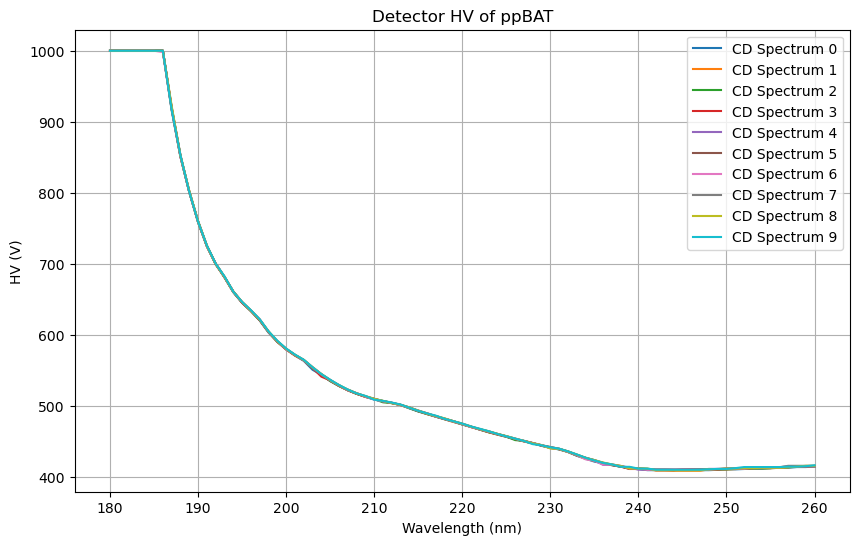

In [25]:
# plot the CD spectrum
plt.figure(figsize=(10, 6))
for i in range(protein_spectra['hv'].shape[1]-2):
    plt.plot(protein_spectra['hv'].iloc[:, 0], protein_spectra['hv'].iloc[:, i+1], label=f'CD Spectrum {i}')
plt.xlabel('Wavelength (nm)')
plt.ylabel('HV (V)')
plt.title(f'Detector HV of {protein_name}')
plt.legend()
plt.grid()
plt.show()

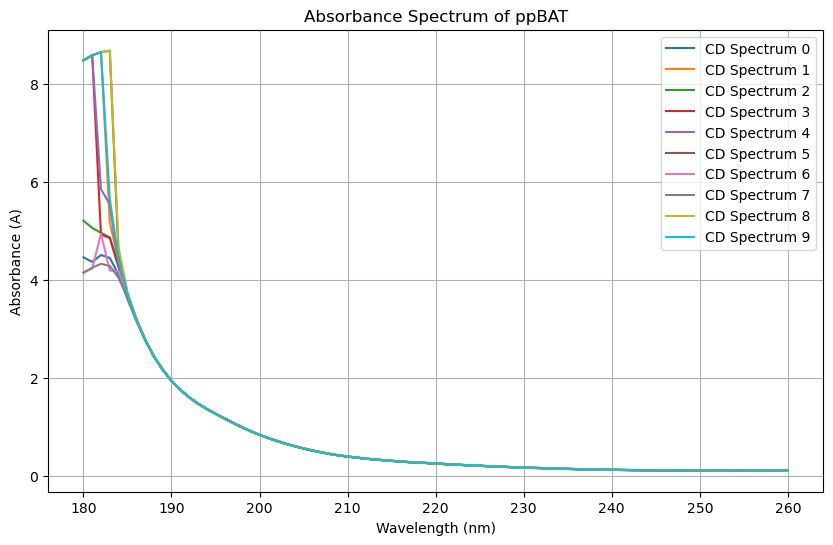

In [44]:
# plot the CD spectrum
plt.figure(figsize=(10, 6))
for i in range(protein_spectra['abs'].shape[1]-2):
    plt.plot(protein_spectra['abs'].iloc[:, 0], protein_spectra['abs'].iloc[:, i+1], label=f'CD Spectrum {i}')
plt.xlabel('Wavelength (nm)')
plt.ylabel('Absorbance (A)')
plt.title(f'Absorbance Spectrum of {protein_name}')
plt.legend()
plt.grid()
plt.show()

## Step 7: Data Smoothing

Raw CD spectra often contain noise. We use Savitzky-Golay filtering to smooth the data while preserving spectral features.

The Savitzky-Golay filter fits a polynomial to a moving window of data points.

**Key parameters:**
- `window_length`: Length of the smoothing window (must be odd). Larger windows = more smoothing but may lose fine details.
- `polyorder`: Polynomial order (typically 2-4). Higher order can fit complex shapes but may overfit noise.

Try different window lengths to see the effect on smoothing and residuals!

In [27]:
def filter_test(cd_df, window_lengths):
    #create empty dataframe to store the results
    results_df = pd.DataFrame()
    results_df['Wavelength'] = cd_df.iloc[:, 0]
    for window_length in window_lengths:
        results_df[f'CD_Smoothed_{window_length}'] = savgol_filter(cd_df['CD_Average'], window_length=window_length, polyorder=3)
        results_df[f'Residuals_{window_length}'] = cd_df['CD_Average'] - results_df[f'CD_Smoothed_{window_length}']
    return results_df

The `filter_test` function applies different window lengths to the averaged CD data and calculates residuals (difference between original and smoothed data).

This helps us choose the optimal smoothing parameters.

**Experiment with window_lengths:** Change the list of window lengths to test different smoothing levels. Odd numbers only!

The results show smoothed spectra and residuals for each window length.

In [28]:
window_lengths = [5, 9, 15, 7]
window_lengths.sort()
tested_filters = filter_test(protein_spectra['cd'], window_lengths)

tested_filters

,Wavelength,CD_Smoothed_5,Residuals_5,CD_Smoothed_7,Residuals_7,CD_Smoothed_9,Residuals_9,CD_Smoothed_15,Residuals_15
0,260,-1.180373,-0.008977,-1.193223,0.003873,-1.189723,0.000373,-1.171798,-0.017552
1,259,-1.209499,0.035907,-1.178974,0.005382,-1.181196,0.007604,-1.190007,0.016416
2,258,-1.172609,-0.053861,-1.175833,-0.050637,-1.180544,-0.045926,-1.197563,-0.028907
3,257,-1.170238,0.060456,-1.181038,0.071256,-1.184772,0.074991,-1.197408,0.087626
4,256,-1.180548,-0.033149,-1.197991,-0.015706,-1.190882,-0.022815,-1.192485,-0.021212
...,...,...,...,...,...,...,...,...,...
76,184,40.414616,7.668914,165.587968,-117.504438,-53.641793,101.725323,-66.495164,114.578694
77,183,180.509384,-112.981784,-143.790469,211.318069,-199.736295,267.263895,-116.563183,184.090783
78,182,-399.531279,464.971809,-449.064559,514.505089,-309.426325,374.866855,-179.085410,244.525940
79,181,-958.855194,-309.981206,-509.499159,-759.337241,-332.563708,-936.272692,-255.125566,-1013.710834


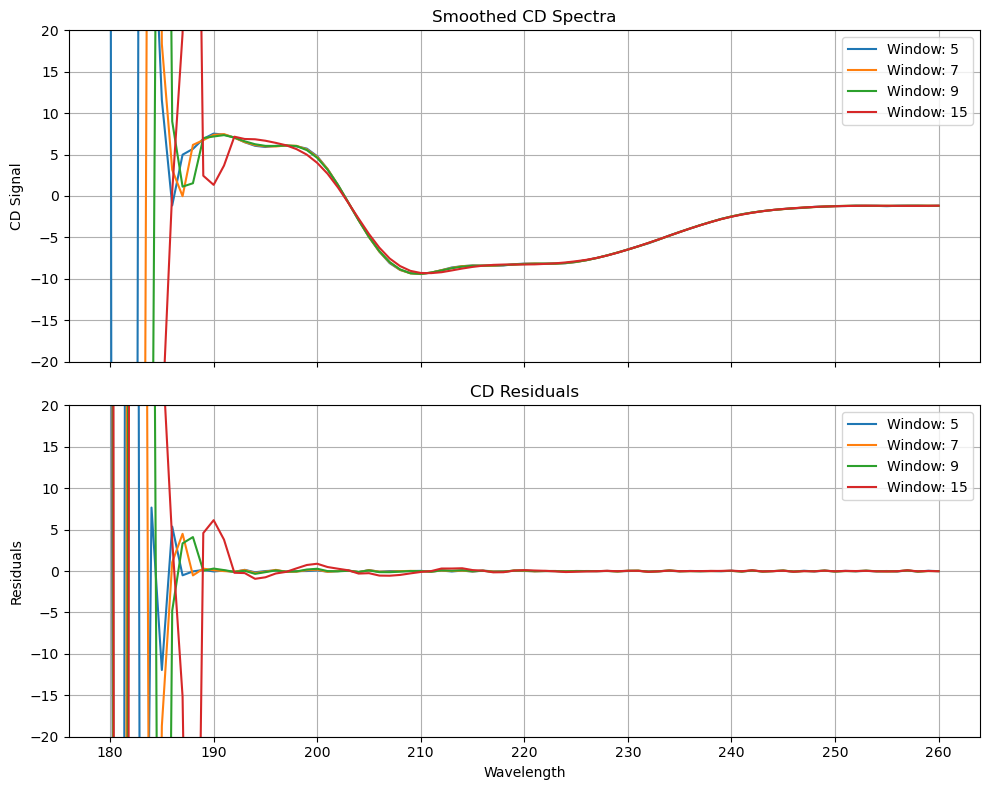

In [45]:
fig, axs = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

for window in window_lengths:
    axs[0].plot(
        tested_filters["Wavelength"],
        tested_filters[f"CD_Smoothed_{window}"],
        label=f'Window: {window}'
    )
axs[0].set_ylabel('CD Signal')
axs[0].set_title('Smoothed CD Spectra')
axs[0].legend()
axs[0].grid(True)
axs[0].set_ylim(-20,20)

for window in window_lengths:
    axs[1].plot(
        tested_filters["Wavelength"],
        tested_filters[f"Residuals_{window}"],
        label=f'Window: {window}'
    )
axs[1].set_xlabel('Wavelength')
axs[1].set_ylabel('Residuals')
axs[1].set_title('CD Residuals')
axs[1].legend()
axs[1].grid(True)

plt.ylim(-20,20)
plt.tight_layout()
plt.show()

The plot shows:
- **Top:** Smoothed CD spectra for different window lengths
- **Bottom:** Residuals (noise) remaining after smoothing

Choose a window length that minimizes noise while preserving spectral features. Too much smoothing can distort peaks!

A good way to find a suitable windowlength is to inspect the residuals. They should show random noise and no distinct features. To find out how features might look like just use a large window (e.g. 20-30). In the residuals you should see clear trends in comparison to the random noise around 0 for small windows and the smoothed CD-spectrum is visibly alterred from the measured data. 

## Step 8: Apply Chosen Smoothing

Based on the filter testing, we select an optimal window length and apply it to both protein and buffer data.

The function adds "CD_Smoothed" and "CD_Smoothed_Residuals" columns to the DataFrame.

In [46]:
def append_savgol(window_length, dataframe):
    dataframe["CD_Smoothed"] = savgol_filter(dataframe[f"CD_Average"], window_length, 3)
    dataframe["CD_Smoothed_Residuals"] = dataframe[f"CD_Average"] - dataframe["CD_Smoothed"]

In [47]:
final_window_length = 9

append_savgol(final_window_length, protein_spectra['cd'])
append_savgol(final_window_length, buffer_spectra['cd'])

Apply smoothing to both protein and buffer spectra using the same chosen window length.

In [48]:
buffer_spectra['cd']

,Wavelength,CD_1,CD_2,CD_3,CD_4,CD_5,CD_Average,CD_Smoothed,CD_Smoothed_Residuals
0,260,-1.24327,-1.020140,-0.85918,-1.167500,-1.208960,-1.099810,-1.149665,0.049855
1,259,-1.43654,-1.374470,-1.27205,-1.114100,-1.349370,-1.309306,-1.183207,-0.126099
2,258,-1.10646,-1.223550,-1.13244,-1.065390,-1.340920,-1.173752,-1.202157,0.028405
3,257,-1.06532,-1.165670,-1.23570,-0.915370,-0.947522,-1.065916,-1.209678,0.143762
4,256,-1.17053,-1.387110,-1.33025,-1.447610,-1.138010,-1.294702,-1.208938,-0.085764
...,...,...,...,...,...,...,...,...,...
76,184,-1.67654,-0.776753,-1.55241,-0.689077,-0.738824,-1.086721,-1.281253,0.194532
77,183,-1.74139,-1.460210,-1.02202,-2.135230,-1.083070,-1.488384,-1.360448,-0.127936
78,182,-1.67694,-1.264980,-1.39280,-2.346180,-1.238150,-1.583810,-1.559964,-0.023846
79,181,-4.11176,-0.896868,-1.48825,-0.572879,-2.504900,-1.914931,-1.927167,0.012236


In [49]:
def baseline_subtraction(protein_df, buffer_df):
    protein_df["CD_Baseline_Subtracted"] = protein_df["CD_Smoothed"] - buffer_df["CD_Smoothed"]

## Step 9: Buffer Baseline Subtraction

CD spectra often have contributions from the buffer solution. We subtract the smoothed buffer spectrum from the smoothed protein spectrum to isolate the protein signal.

This corrects for any CD signal from the solvent or cuvette.

In [50]:
baseline_subtraction(protein_spectra['cd'], buffer_spectra['cd'])

Apply baseline subtraction to get the protein-only CD signal.

In [51]:
protein_spectra['cd']

,Wavelength,CD_1,CD_2,CD_3,CD_4,CD_5,CD_6,CD_7,CD_8,CD_9,CD_10,CD_Average,CD_Smoothed,CD_Smoothed_Residuals,CD_Baseline_Subtracted,MRE
0,260,-1.25820,-1.111830,-1.26317,-1.22314,-1.042020,-1.372960,-1.06658,-1.32660,-1.08391,-1.14509,-1.189350,-1.189723,0.000373,-0.040058,-52.363116
1,259,-1.28713,-1.174620,-1.10951,-1.04506,-0.927993,-1.105090,-1.40061,-1.20895,-1.32742,-1.14953,-1.173591,-1.181196,0.007604,0.002012,2.629459
2,258,-1.15930,-1.121810,-1.26135,-1.32785,-1.322650,-1.124930,-1.32170,-1.24169,-1.21363,-1.16979,-1.226470,-1.180544,-0.045926,0.021612,28.251116
3,257,-1.36282,-0.724389,-1.32591,-1.13296,-0.950356,-0.925108,-1.24992,-1.15669,-1.21003,-1.05963,-1.109781,-1.184772,0.074991,0.024906,32.556835
4,256,-1.28333,-1.266530,-1.16107,-1.38342,-1.132370,-1.105550,-1.12929,-1.31236,-1.27660,-1.08645,-1.213697,-1.190882,-0.022815,0.018055,23.601597
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76,184,11.98060,55.782100,-15.92490,20.64130,35.717500,179.936000,43.55310,-59.84630,191.23900,17.75690,48.083530,-53.641793,101.725323,-52.360540,-68445.150077
77,183,-73.33420,144.506000,-346.70800,50.75620,-324.267000,390.701000,-23.37100,-78.09730,-26.33570,961.42600,67.527600,-199.736295,267.263895,-198.375847,-259314.832816
78,182,-51.56670,-183.386000,299.42900,224.11900,-319.439000,135.764000,43.08020,-11.00820,-241.32800,758.74100,65.440530,-309.426325,374.866855,-307.866361,-402439.687692
79,181,80.29480,188.126000,-225.74800,-12453.50000,-158.396000,-178.034000,-14.12460,-38.38920,-199.65400,311.06100,-1268.836400,-332.563708,-936.272692,-330.636541,-432204.628238


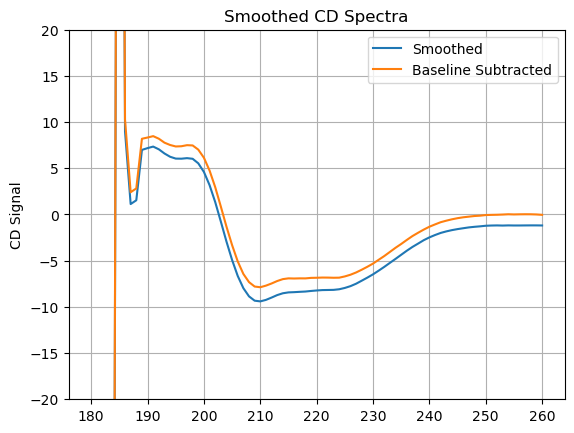

In [53]:
# plot from protein_spectra['cd'] the smoothed and baseline subtracted spectra
plt.plot(protein_spectra['cd']["Wavelength"], protein_spectra['cd']['CD_Smoothed'], label='Smoothed')
plt.plot(protein_spectra['cd']["Wavelength"], protein_spectra['cd']['CD_Baseline_Subtracted'], label='Baseline Subtracted')
plt.ylabel('CD Signal')
plt.title('Smoothed CD Spectra')
plt.legend()
plt.ylim(-20,20)
plt.grid(True)


Plot the smoothed and baseline-subtracted spectra to see the final processed data.

In [54]:
def cd_to_mre(dataframe, MW, concentration, path_length, resn):
    dataframe['MRE'] = (dataframe['CD_Baseline_Subtracted'] * MW / (path_length * concentration * (resn-1) * 10))

## Step 10: Convert to Mean Residue Ellipticity (MRE)

CD data is typically reported as Mean Residue Ellipticity (MRE) in units of deg cm² dmol⁻¹.

The conversion formula is:

$\mathrm{MRE} = \frac{\theta \cdot MW}{l \cdot c \cdot (N - 1) \cdot 10}$

Where:
- $\theta$: CD-signal [mdeg]
- $MW$: molecular weight [Da]
- $l$: path_length [cm]
- $c$: protein concentration [g/L]
- $N$: number of amino acids

**Important:** Ensure all parameters are correctly set at the beginning!

In [55]:
cd_to_mre(protein_spectra['cd'], protein_MW, protein_concentration, path_length, protein_resn)

Apply the MRE conversion using the protein parameters defined earlier.

In [56]:
protein_spectra['cd']

,Wavelength,CD_1,CD_2,CD_3,CD_4,CD_5,CD_6,CD_7,CD_8,CD_9,CD_10,CD_Average,CD_Smoothed,CD_Smoothed_Residuals,CD_Baseline_Subtracted,MRE
0,260,-1.25820,-1.111830,-1.26317,-1.22314,-1.042020,-1.372960,-1.06658,-1.32660,-1.08391,-1.14509,-1.189350,-1.189723,0.000373,-0.040058,-52.363116
1,259,-1.28713,-1.174620,-1.10951,-1.04506,-0.927993,-1.105090,-1.40061,-1.20895,-1.32742,-1.14953,-1.173591,-1.181196,0.007604,0.002012,2.629459
2,258,-1.15930,-1.121810,-1.26135,-1.32785,-1.322650,-1.124930,-1.32170,-1.24169,-1.21363,-1.16979,-1.226470,-1.180544,-0.045926,0.021612,28.251116
3,257,-1.36282,-0.724389,-1.32591,-1.13296,-0.950356,-0.925108,-1.24992,-1.15669,-1.21003,-1.05963,-1.109781,-1.184772,0.074991,0.024906,32.556835
4,256,-1.28333,-1.266530,-1.16107,-1.38342,-1.132370,-1.105550,-1.12929,-1.31236,-1.27660,-1.08645,-1.213697,-1.190882,-0.022815,0.018055,23.601597
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76,184,11.98060,55.782100,-15.92490,20.64130,35.717500,179.936000,43.55310,-59.84630,191.23900,17.75690,48.083530,-53.641793,101.725323,-52.360540,-68445.150077
77,183,-73.33420,144.506000,-346.70800,50.75620,-324.267000,390.701000,-23.37100,-78.09730,-26.33570,961.42600,67.527600,-199.736295,267.263895,-198.375847,-259314.832816
78,182,-51.56670,-183.386000,299.42900,224.11900,-319.439000,135.764000,43.08020,-11.00820,-241.32800,758.74100,65.440530,-309.426325,374.866855,-307.866361,-402439.687692
79,181,80.29480,188.126000,-225.74800,-12453.50000,-158.396000,-178.034000,-14.12460,-38.38920,-199.65400,311.06100,-1268.836400,-332.563708,-936.272692,-330.636541,-432204.628238


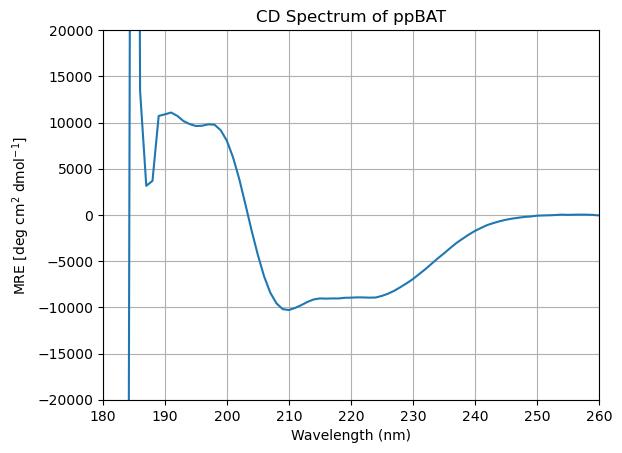

In [57]:
plt.plot(protein_spectra['cd']['Wavelength'], protein_spectra['cd']['MRE'])
plt.xlabel('Wavelength (nm)')
plt.ylabel('MRE [deg cm$^{2}$ dmol$^{-1}$]')
plt.xlim(min(protein_spectra['cd']["Wavelength"]), max(protein_spectra['cd']["Wavelength"]))
plt.grid(True)
plt.title(f'CD Spectrum of {protein_name}')
plt.ylim(-20000,20000)
plt.show()

Plot the final MRE spectrum. This is the standard way to present CD data for secondary structure analysis. The measured ellipticity signal is normalized to the concentration of peptide bonds (the signal producing unit) and the path length of the cuvette. This makes different measurements comparable, even between different proteins. 

In principle it is possible to estimate secondary structure content from CD-spectra (content of $\alpha$-helices, $\beta$-strands and disordered regions). You can try it yourself with https://spc.embl-hamburg.de/app/chirakit (mind that it seems not to work in firefox. Use a chrome-based browser.). Simply export the wavelengths and MRE to a .csv file and upload it to the server. Follow the described tutorial steps. 

    output_df = protein_spectra['cd'][["Wavelength", "MRE"]]
    output_df.to_csv(os.path.join(base_directory, f"{protein_name}_CD_MRE.csv"), index=False)

Treat the secondary structure estimation as **Estimations**. The quality is highly dependant on your data quality. Errors protein concentration determination are factorized by the number of residues! Also highly sensitive parts of the spectrum are in a wavelength range that is difficult to measure (170-200 nm). 

A good rule of thumb is to look at the order of magnitude for the signal. Purely $\alpha$-helical, well folded protein should give two distinct minima at 208 and 222 nm that reach values around -20 000 to -30 000 $deg \cdot cm² \cdot dmol^{-1}$. $\beta$-sheet proteins give a minimum around 215 nm reaching -10 000 to -20 000 $deg \cdot cm² \cdot dmol^{-1}$. Folded protein should show a maximum below 200 nm. Inversely unfolded protein gives a minimum below 200 nm and positive signal above 210 nm.

In [58]:
def trusted_cutoff(dataframe):
    cutoff_wavelength = dataframe["Wavelength"][0]
    for i, value in enumerate(dataframe["Abs_Average"]):
        if value > 2:
            cutoff_wavelength = dataframe["Wavelength"].iloc[i-1]
            break

    return cutoff_wavelength


## Step 11: Determine Reliable Wavelength Range

High absorbance makes CD measurements inaccurate. Absorbance above 2 means that only 1 % of the incident light reaches the detector. We will define this as upper limit for a reliable measurement. We will find the wavelength where absorbance first exceeds 2 and use this as the lower limit for reliable CD data. As discussed in the beginning, during the measurement, the detector HV is increased to compensate for high absorbance. The two values correlate directly and both can be used for the definition of a cutoff criterium.

This ensures we only analyze data in the optically transparent region.

In [59]:
cutoff = trusted_cutoff(protein_spectra['abs'])
print(cutoff)

190


Calculate the cutoff wavelength based on absorbance data.

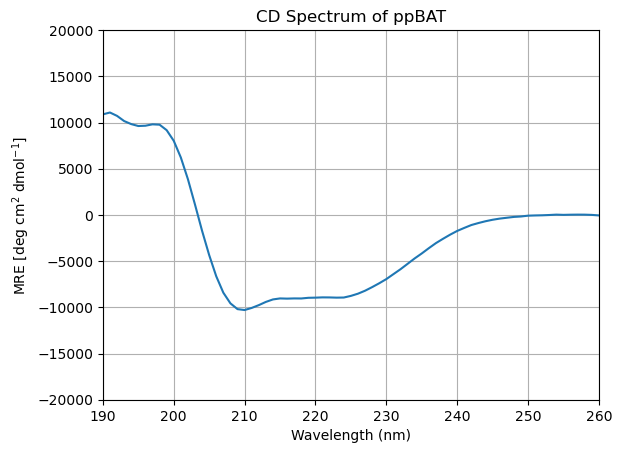

In [60]:
plt.plot(protein_spectra['cd']['Wavelength'], protein_spectra['cd']['MRE'])
plt.xlabel('Wavelength (nm)')
plt.ylabel('MRE [deg cm$^{2}$ dmol$^{-1}$]')
plt.xlim(cutoff, max(protein_spectra['cd']["Wavelength"]))
plt.grid(True)
plt.title(f'CD Spectrum of {protein_name}')
plt.ylim(-20000,20000)
plt.show()

## Final Result: Reliable MRE Spectrum

Plot the MRE spectrum starting from the reliable wavelength range (above the absorbance cutoff).

This spectrum can now be used for secondary structure analysis or comparison with reference spectra.

**Key takeaways:**
- Raw CD data needs processing (averaging, smoothing, baseline subtraction)
- Parameters like concentration, MW, and path length are crucial for MRE calculation
- Absorbance limits the usable wavelength range
- Experiment with smoothing parameters to optimize signal-to-noise ratio

Try changing the protein parameters or data files to analyze different samples!